# traQmania 05 — Real quantum hardware

So far every expectation value was computed *exactly* on a statevector
simulator. Real quantum processors give you neither exactness nor speed: you
get **shot noise** (finite samples of a probability distribution), **device
noise** (decoherence, gate errors, readout errors), and **latency** (job
scheduling, queues). This notebook walks the trained driver down that ladder.

## The backend taxonomy

| backend | what it is | exact? | noise | speed |
|---|---|---|---|---|
| `fastsim` | numpy statevector + adjoint gradients | yes | none | ~µs/eval, ~ms/update |
| `aer_statevector` | Qiskit Aer `EstimatorV2`, precision 0 | yes | none | ms/eval |
| `aer_shots` | Aer with 1024-shot sampling | no | shot noise | ms/eval |
| `aer_noisy` | Aer + device noise model (fake backend) | no | shot + gate/readout | ~0.1 s/eval |
| real hardware | IBM Quantum device via `qiskit-ibm-runtime` | no | the real thing | seconds/job + queue |

The first four run locally. The last needs an IBM Quantum account — the cells
at the end only execute if a token is configured, and are skipped otherwise.

In [1]:
# On Binder (QuBins images) this repo arrives via nbgitpuller without being
# pip-installed; install it from GitHub only if the import fails.
try:
    import traqmania  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/JanLahmann/traQmania

import os

import matplotlib.pyplot as plt
import numpy as np

# CI sets this to skip the (fake-)hardware cells; harmless when unset.
SKIP_HW = os.environ.get("TRAQMANIA_SKIP_HW") == "1"

## The trained driver, off the exact simulator

We load the bundled trained oval weights and evaluate the *same greedy policy*
under increasing realism. Note what we are doing here: **inference on a noisy
backend** — every steering decision of the rollout is a 4-observable estimation
of the circuit.

In [2]:
from pathlib import Path

import traqmania
from traqmania.agents.quantum import QuantumQFunction, make_qfunction
from traqmania.config import load_config
from traqmania.env.racing_env import RacingEnv
from traqmania.env.track import Track

WEIGHTS = Path(traqmania.__file__).parent / "weights" / "quantum_oval.npz"
params = np.load(WEIGHTS)["params"]
config = load_config()
track = Track.load("oval")


def rollout(qfunc, spawn_seed, max_steps=600):
    """Greedy episode; returns (laps, best_lap_s, steps).

    The first lap is a slow standing-start out-lap; with the default step
    budget the car gets flying laps too, so best_lap_s is a flying lap.
    """
    env = RacingEnv(track, config, n_envs=1, seed=spawn_seed)
    obs, best_lap, laps, steps = env.reset(), np.inf, 0, 0
    for _ in range(max_steps):
        obs, _r, done, info = env.step(np.argmax(qfunc.q_values(obs), axis=1))
        steps += 1
        if not np.isnan(info["last_lap_time"][0]):
            best_lap = min(best_lap, info["last_lap_time"][0])
        laps = max(laps, info["lap"][0])
        if done[0]:
            break
    return laps, best_lap, steps


fast = QuantumQFunction(config["circuit"])
fast.set_params(params)
laps, best, steps = rollout(fast, spawn_seed=0)
print(f"fastsim (exact) reference: {laps} laps in {steps} decisions, "
      f"best (flying) lap {best:.1f} s")

fastsim (exact) reference: 3 laps in 600 decisions, best (flying) lap 14.4 s


In [3]:
import time

print("1024-shot sampling (aer_shots), three spawn positions:")
for spawn_seed in (0, 1, 2):
    q = make_qfunction("aer_shots", config["circuit"], seed=7, shots=1024)
    q.set_params(params)
    t0 = time.perf_counter()
    laps, best, steps = rollout(q, spawn_seed)
    lap_s = f"best {best:.1f} s" if laps else "no lap"
    print(f"  spawn {spawn_seed}: {laps} laps, {lap_s} "
          f"({steps} decisions in {time.perf_counter() - t0:.1f} s wall)")

1024-shot sampling (aer_shots), three spawn positions:


  spawn 0: 3 laps, best 14.4 s (600 decisions in 4.8 s wall)


  spawn 1: 3 laps, best 14.4 s (600 decisions in 4.8 s wall)


  spawn 2: 3 laps, best 14.4 s (600 decisions in 4.6 s wall)


With 1024 shots each $\langle Z_a \rangle$ estimate has a standard error of
about $1/\sqrt{1024} \approx 0.03$ — and the *trained output head multiplies
that noise by* $|w_a|$, so near-ties between Q-values can flip. The trained
oval policy usually shrugs this off: at the states it actually visits the
Q-value gaps are wide enough that it laps at exact-reference pace.

Now add a **device noise model**. When `qiskit-ibm-runtime` is installed,
`aer_noisy` uses the calibrated noise model of a real (retired) 5-qubit IBM
device — `FakeManilaV2` — including its gate errors and readout errors, with
the circuit transpiled to the device's native gates and coupling map.

In [4]:
print("device noise model + shots (aer_noisy), two spawn positions:")
for spawn_seed in (0, 1):
    q = make_qfunction("aer_noisy", config["circuit"], seed=7, shots=1024)
    q.set_params(params)
    t0 = time.perf_counter()
    # capped at 300 decisions: noisy simulation costs ~0.1 s per decision
    laps, best, steps = rollout(q, spawn_seed, max_steps=300)
    lap_s = f"best {best:.1f} s" if laps else "no lap"
    print(f"  spawn {spawn_seed}: {laps} laps, {lap_s} "
          f"({steps} decisions in {time.perf_counter() - t0:.1f} s wall)")

device noise model + shots (aer_noisy), two spawn positions:


  spawn 0: 0 laps, no lap (61 decisions in 8.3 s wall)


  spawn 1: 0 laps, no lap (59 decisions in 7.9 s wall)


Honest result: under a real device's noise model the driver is on the ragged
edge. Depending on the run it sometimes gets a (slow) lap in and often clips a
wall within a few seconds — and the outcome *changes between executions*,
because the layout/routing pass that maps the circuit onto the device is
stochastic, so each run races with a slightly different noise profile. Device
noise compresses and biases the $\langle Z \rangle$ values (depolarization
pulls them toward 0), which distorts Q-value *ordering* — and ordering is all
a greedy policy has.

## Why training stays on the simulator

Could we have *trained* on hardware instead of just driving? Count the cost of
one double-DQN gradient step (batch 32, measured in
[notebook 03](03_quantum_circuits_as_q_functions.ipynb)):

| | one update | 20k updates (a typical run) |
|---|---|---|
| fastsim + adjoint | **~3.4 ms** | ~1 minute |
| `EstimatorQNN` + param-shift | **~20.5 s** | ~5 days of pure compute |

That ~6000× gap is *before* hardware realities: on a real device each
param-shift update is 2 × 48 parameter-shifted circuit batches submitted as
jobs, plus queue time. Training on hardware with param-shift is simply not a
sane use of QPU hours at this scale. Hence traQmania's split: **train on the
exact simulator, run inference on hardware.**

## The hardware sprint: SPSA

There is a middle path for *touching up* trained weights on hardware:
**SPSA** (simultaneous perturbation stochastic approximation). Instead of 96
evaluations per gradient, SPSA estimates a descent direction from **exactly 2
loss evaluations per iteration** — perturb all 56 parameters simultaneously by
a random ±1 vector $\Delta$, evaluate the loss at $\theta \pm c\Delta$, and
step along $\frac{f_+ - f_-}{2c}\Delta^{-1}$. It's the standard trick for
variational algorithms on real devices (VQE runs on hardware use it for the
same reason).

`traqmania.hardware.spsa_sprint` implements this: the replay batch and
double-DQN targets are computed once in fastsim, then each SPSA iteration costs
two Estimator jobs on the backend. Below we run a short sprint on a **fake
backend** (local simulation of a real device, no account needed).

backend: fake_manila (5 qubits, simulated locally)


15 SPSA iterations = 31 Estimator jobs in 9.1 s
TD loss: 875.1 -> 717.8
greedy return (exact eval): 1423.8 -> 344.7


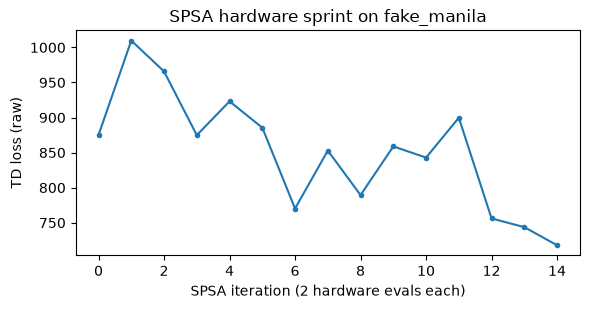

In [5]:
try:
    from traqmania.hardware import get_backend, run_hardware_lap, spsa_sprint
    HAS_HW = True
except ImportError:
    HAS_HW = False
    print("traqmania.hardware is not available in this build; "
          "the remaining cells explain what it would do.")

if HAS_HW and not SKIP_HW:
    backend = get_backend(use_fake=True)  # FakeManilaV2: local noise-model twin
    print(f"backend: {backend.name} ({backend.num_qubits} qubits, simulated locally)")
    result = spsa_sprint("oval", WEIGHTS, backend, iterations=15, batch=32)
    print(f"{result['iterations']} SPSA iterations = "
          f"{2 * result['iterations'] + 1} Estimator jobs in {result['seconds']:.1f} s")
    print(f"TD loss: {result['loss_history'][0]:.1f} -> {result['loss_history'][-1]:.1f}")
    print(f"greedy return (exact eval): {result['return_before']:.1f} -> "
          f"{result['return_after']:.1f}")
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.plot(result["loss_history"], marker="o", ms=3)
    ax.set(xlabel="SPSA iteration (2 hardware evals each)", ylabel="TD loss (raw)",
           title=f"SPSA hardware sprint on {backend.name}")
    plt.tight_layout()
    plt.show()
elif HAS_HW:
    print("TRAQMANIA_SKIP_HW=1 -- skipping the fake-backend SPSA sprint.")

Read the sprint output critically. Every loss evaluation is itself noisy
(shots, device noise, and a stochastic transpilation layout), so a short
sprint is swingy: rerun the cell and the TD loss may end lower or higher than
it started — and the *greedy return usually gets worse either way*, because a
noisy loss over one replay batch is a blunt instrument and DQN policies are
brittle to small weight changes. A sprint demonstrates the *mechanics* (2
evaluations per update on a device, versus 96 for param-shift); it is not a
training method that competes with the simulator.

## A lap where every decision is a quantum job

`run_hardware_lap` drives one car greedily with each steering decision
evaluated on the backend, inside a runtime `Session`. On the fake backend this
also gives an honest preview of per-decision latency:

went off track (device noise!) after 14 decisions, 91 ms per decision


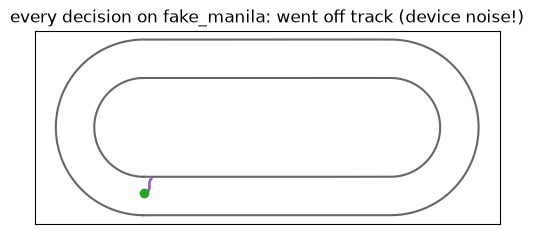

In [6]:
if HAS_HW and not SKIP_HW:
    lap = run_hardware_lap("oval", WEIGHTS, backend, max_decisions=200)
    verdict = (f"lapped in {lap['best_lap_s']:.1f} s" if lap["lapped"]
               else "went off track (device noise!)")
    print(f"{verdict} after {lap['decisions']} decisions, "
          f"{lap['seconds_per_decision'] * 1e3:.0f} ms per decision")
    traj = np.array(lap["trajectory"])
    cl, hw_ = track.centerline, track.half_width
    fig, ax = plt.subplots(figsize=(6, 5))
    for sign in (+1.0, -1.0):
        b = cl + sign * hw_ * track.normals
        b = np.vstack([b, b[:1]])
        ax.plot(b[:, 0], b[:, 1], color="0.4", lw=1.5)
    ax.plot(traj[:, 0], traj[:, 1], color="tab:purple", lw=2)
    ax.plot(*traj[0, :2], "o", color="tab:green")
    ax.set_aspect("equal"), ax.set_xticks([]), ax.set_yticks([])
    ax.set_title(f"every decision on {backend.name}: {verdict}")
    plt.show()
elif HAS_HW:
    print("TRAQMANIA_SKIP_HW=1 -- skipping the fake-backend lap.")

## Real hardware

The exact same two calls run on a physical IBM Quantum device — only the
backend changes. The cell below **only executes if you have configured an IBM
Quantum API token** (create one at
[quantum.cloud.ibm.com](https://quantum.cloud.ibm.com), then
`export QISKIT_IBM_TOKEN=...` before starting Jupyter, or save it once with
`QiskitRuntimeService.save_account(...)`). Never paste a token into a notebook
cell — notebooks get committed.

Expect minutes to hours of queue time, and per-decision latencies of seconds:
a full closed-loop lap (hundreds of sequential decisions) is a *long* session,
which is why the default below only takes a few decisions to prove the loop
closes on real silicon.

In [7]:
if HAS_HW and not SKIP_HW and os.environ.get("QISKIT_IBM_TOKEN"):
    real = get_backend()  # least-busy real device your account can access
    print(f"running on {real.name} ({real.num_qubits} qubits) -- this may queue...")
    lap = run_hardware_lap("oval", WEIGHTS, real, max_decisions=10)
    print(f"{lap['decisions']} decisions on {real.name}, "
          f"{lap['seconds_per_decision']:.1f} s per decision"
          + (f", lapped in {lap['best_lap_s']:.1f} s" if lap["lapped"] else ""))
else:
    print("Skipped: set QISKIT_IBM_TOKEN (and unset TRAQMANIA_SKIP_HW) "
          "to drive on a real IBM Quantum device.")

Skipped: set QISKIT_IBM_TOKEN (and unset TRAQMANIA_SKIP_HW) to drive on a real IBM Quantum device.


## Where this leaves us

- The **exact simulator** is where learning happens (3.4 ms vs 20.5 s per
  update: no contest at this scale).
- **Shots** the trained policy tolerates; **device noise** it only sometimes
  survives — noise-robustness of RL *policies* (not just expectation values) is
  a real, underexplored question you can poke at right here.
- **SPSA** is the only sensible way to *update* parameters on hardware today
  (2 evals/iteration), and even then: sprints, not training runs.
- The full game (`./run.sh`) wires these same backends into a live UI — watch
  the ⟨Z⟩ gauges wobble under noise while the quantum driver races.

*That's the series. Back to [01 — the racing environment](01_the_racing_env.ipynb),
or go race the quantum driver yourself.*